# Lysosome Masking for Hannah Bailey

## Load images

In [1]:
from pathlib import Path

img_dir = Path("/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data")
print(img_dir)

imgs = list(sorted(img_dir.glob('*.tif')))
print(imgs)

img = imgs[5]

/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data
[PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data/20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep1_011_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data/20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep1__MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data/20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_009_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data/20250311_647pR10_488GFAP_561Lamp1_NG_rep1_020_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data/20250311_647pR10_488GFAP_561Lamp1_Unt_rep1_012_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/data/20250331_647pR10_568Lamp1_GFAP488_V1_Rep1_008_MIP.tif')]


In [2]:
import tifffile 
import os

img_1 = tifffile.imread(img)

print(img_1)
print(img_1.shape)

print(os.path.basename(img))

[[[ 115  110  115 ...  116  110  114]
  [ 111  111  113 ...  116  110  116]
  [ 112  111  120 ...  111  111  109]
  ...
  [ 113  113  119 ...  110  109  109]
  [ 108  113  118 ...  118  109  111]
  [ 110  109  111 ...  115  111  110]]

 [[ 111  110  111 ...  115  120  119]
  [ 110  111  109 ...  109  124  132]
  [ 109  108  110 ...  117  126  145]
  ...
  [ 112  108  112 ...  106  109  107]
  [ 107  107  115 ...  110  109  107]
  [ 109  107  108 ...  107  105  106]]

 [[2829 2743 2660 ...  197  196  222]
  [3091 2898 2617 ...  194  188  194]
  [3927 3459 2938 ...  185  196  181]
  ...
  [ 229  222  243 ...  812  850  805]
  [ 248  264  300 ...  897  858  752]
  [ 297  292  321 ...  977  886  774]]

 [[ 135  139  137 ...  131  130  134]
  [ 129  134  134 ...  130  126  130]
  [ 138  133  142 ...  129  130  128]
  ...
  [ 136  132  134 ...  129  129  129]
  [ 133  134  130 ...  129  124  123]
  [ 138  136  126 ...  125  123  130]]]
(4, 1200, 1200)
20250331_647pR10_568Lamp1_GFAP488_V1_Rep

## Preview an image

In [3]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta"
                 )

viewer.add_image(img_1[1], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red"
                 )

viewer.add_image(img_1[2], 
                 name='GFAP',
                 blending="additive",
                 colormap="green")

viewer.add_image(img_1[3], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue")

<Image layer 'DAPI' at 0x157f8c550>

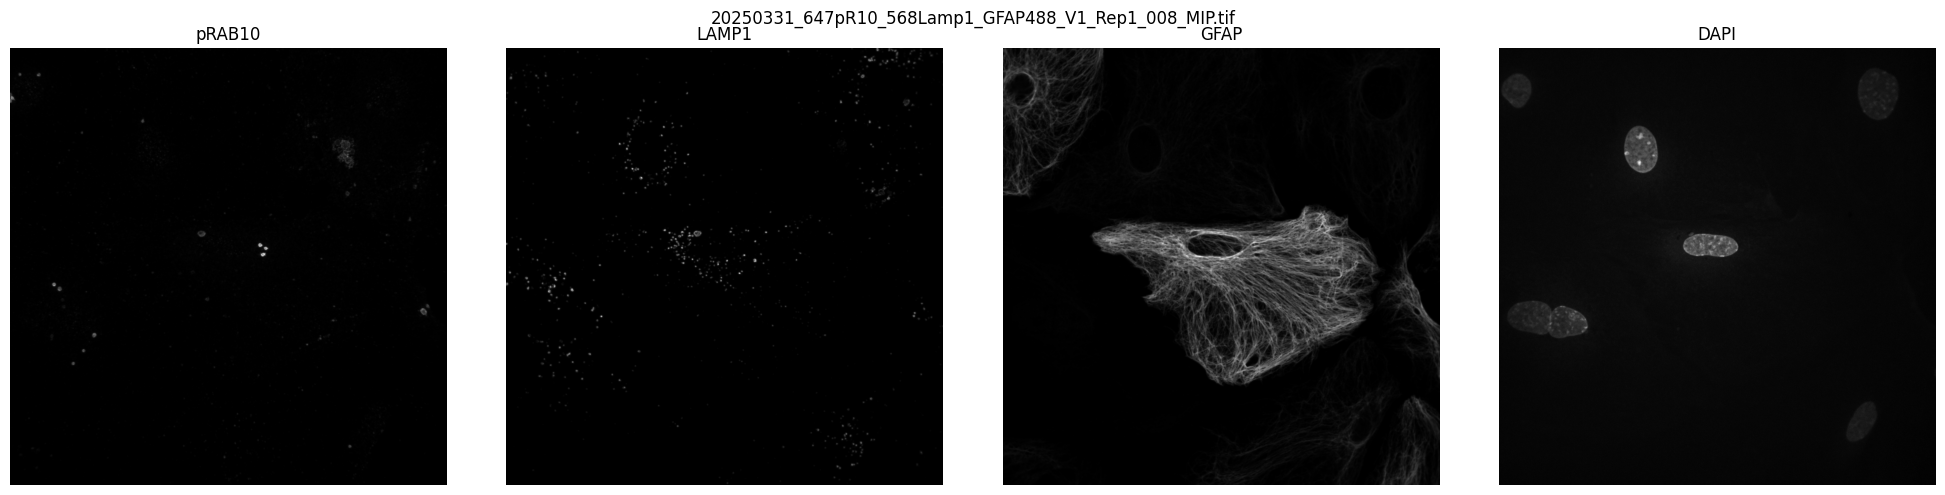

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(os.path.basename(img))

axs[0].imshow(img_1[0], cmap='gray') 
axs[0].set_title("pRAB10")
axs[0].axis("off")

axs[1].imshow(img_1[1], cmap = "gray")
axs[1].set_title("LAMP1")
axs[1].axis("off")

axs[2].imshow(img_1[2], cmap='gray')
axs[2].set_title("GFAP")
axs[2].axis("off")

axs[3].imshow(img_1[3], cmap='gray')
axs[3].set_title("DAPI")
axs[3].axis("off")

plt.tight_layout()
plt.show()

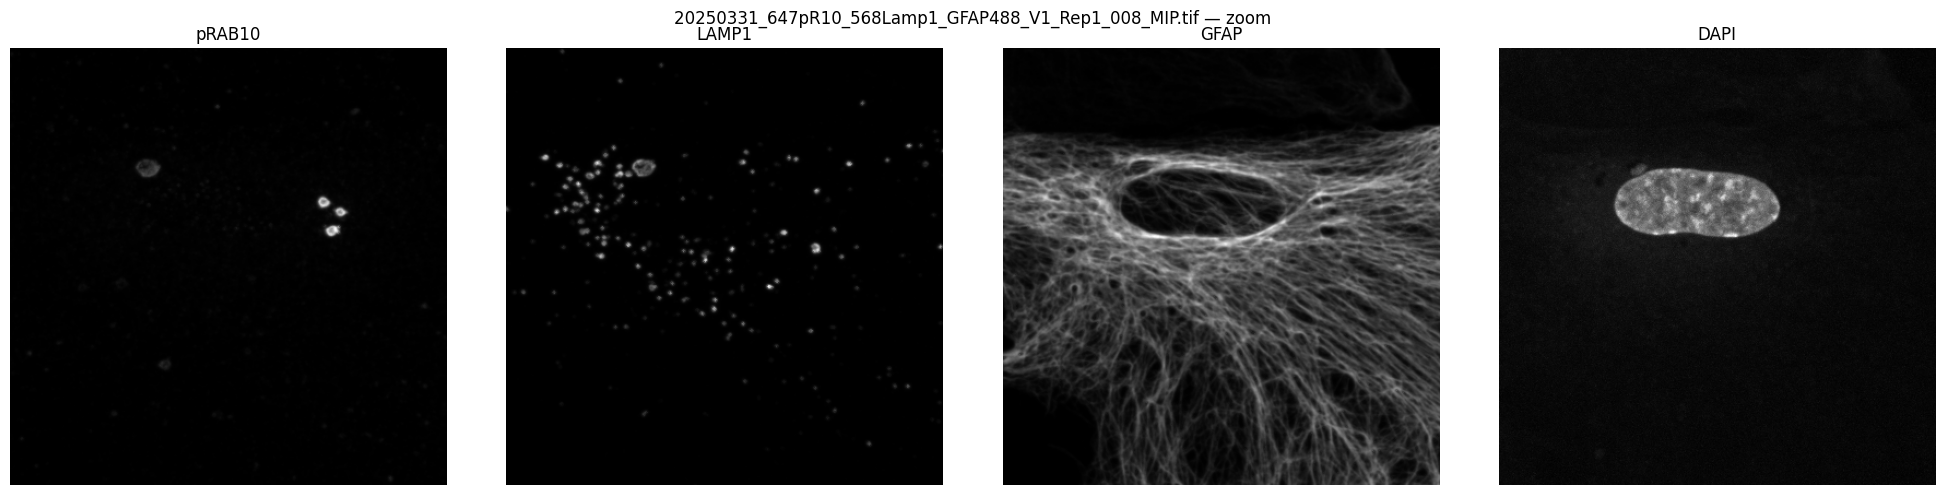

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"{os.path.basename(img)} — zoom")

axs[0].imshow(img_1[0, 400:800, 400:800], cmap='gray') 
axs[0].set_title("pRAB10")
axs[0].axis("off")

axs[1].imshow(img_1[1, 400:800, 400:800], cmap = "gray")
axs[1].set_title("LAMP1")
axs[1].axis("off")

axs[2].imshow(img_1[2, 400:800, 400:800], cmap='gray')
axs[2].set_title("GFAP")
axs[2].axis("off")

axs[3].imshow(img_1[3, 400:800, 400:800], cmap='gray')
axs[3].set_title("DAPI")
axs[3].axis("off")

plt.tight_layout()
plt.show()

### ID lysosomes from a single image

In [6]:
from scipy.ndimage import gaussian_laplace
from skimage import filters, morphology
from scipy import ndimage as ndi
import numpy as np
from scipy.stats import norm

# Paramaters - same as ACIS standard
intensity_scaling_param = [3, 19]
min_lysosome_area = 5
blur_sigma = 1
log_sigma_1, log_cutoff_1 = 2.5, 0.07
log_sigma_2, log_cutoff_2 = 2.5, 0.07
log_sigma_3, log_cutoff_3 = 1, 0.01
vesselness_sigma = [1]
vesselness_cutoff = 0.15

lys_ch = img_1[1].copy().astype(float)

# Normalize image
#image_norm = (lys_ch - np.min(lys_ch)) / (np.max(lys_ch) - np.min(lys_ch))

# Normalize to normal distribution
m, s = norm.fit(lys_ch.flatten())
stretch_min = max(m - intensity_scaling_param[0] * s, lys_ch.min())
stretch_max = min(m + intensity_scaling_param[1] * s, lys_ch.max())
lys_ch_n = np.clip(lys_ch, stretch_min, stretch_max)
image_norm = (lys_ch_n - stretch_min) / (stretch_max - stretch_min)

# Blur image
blurred = filters.gaussian(image_norm, sigma=blur_sigma)

# Identify blobs
log_1 = -1 * (log_sigma_1**2) * gaussian_laplace(blurred, sigma=log_sigma_1)
log_2 = -1 * (log_sigma_2**2) * gaussian_laplace(blurred, sigma=log_sigma_2)
log_3 = -1 * (log_sigma_3**2) * gaussian_laplace(blurred, sigma=log_sigma_3)

log_1_mask = log_1 > log_cutoff_1
log_2_mask = log_2 > log_cutoff_2
log_3_mask = log_3 > log_cutoff_3

log_mask = np.logical_or(log_1_mask, log_2_mask)
log_mask = np.logical_or(log_mask, log_3_mask)

# Identify vessels
vesselness = filters.frangi(blurred, sigmas=vesselness_sigma, black_ridges=False) > vesselness_cutoff
combined = np.logical_or(log_mask, vesselness)

filled = ndi.binary_fill_holes(combined)
lysosome_mask = morphology.remove_small_objects(filled, min_size=min_lysosome_area)

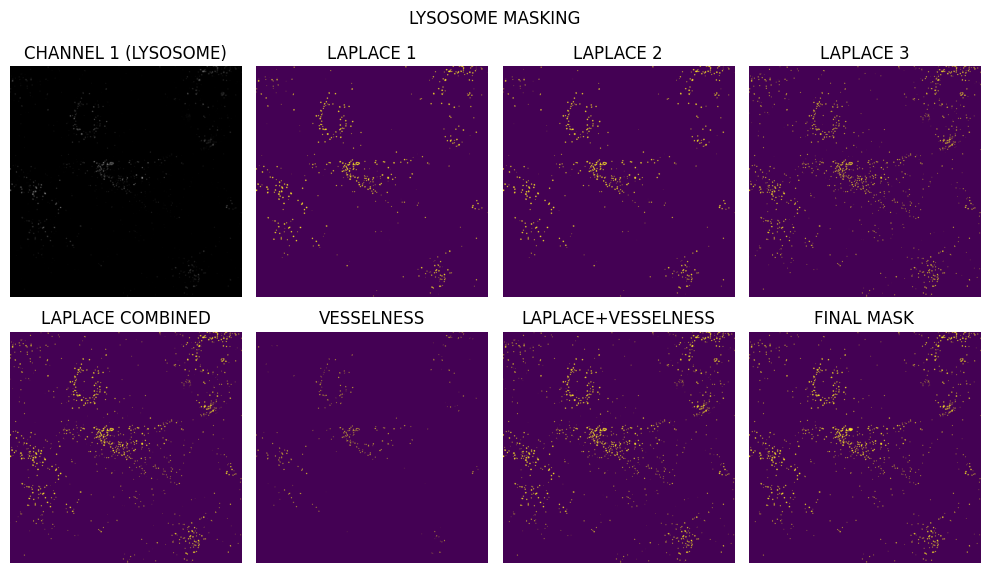

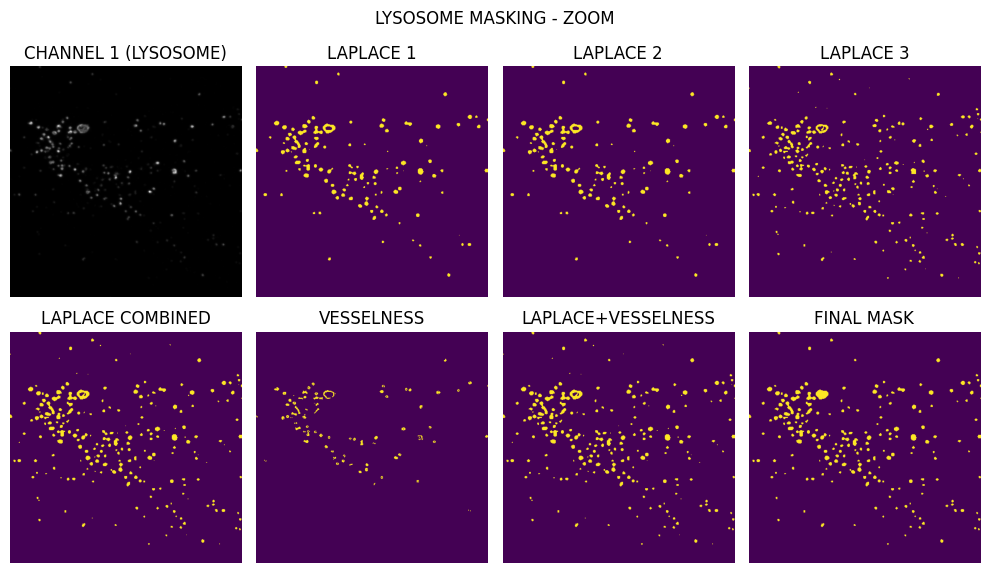

In [7]:
fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING")

axs[0,0].imshow(img_1[1], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask)
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask)
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask)
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask)
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness)
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined)
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(lysosome_mask)
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING - ZOOM")

axs[0,0].imshow(img_1[1, 400:800, 400:800], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask[400:800, 400:800])
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask[400:800, 400:800])
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask[400:800, 400:800])
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask[400:800, 400:800])
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness[400:800, 400:800])
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined[400:800, 400:800])
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(lysosome_mask[400:800, 400:800])
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [8]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta"
                 )

viewer.add_image(img_1[1], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red"
                 )

viewer.add_image(img_1[2], 
                 name='GFAP',
                 blending="additive",
                 colormap="green")

viewer.add_image(img_1[3], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue")

viewer.add_image(lysosome_mask, 
                 name='LYSOSOME MASK')

<Image layer 'LYSOSOME MASK' at 0x1695225d0>